# Homework 4 — Distance Metrics and Correlation on the Breast Cancer Dataset

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

A distance metric is the assumption a clustering algorithm makes about what "similar" means, and different metrics make different assumptions. Here five metrics are computed on the Wisconsin Breast Cancer data, their distance matrices are visualized and compared, and the comparison is settled by clustering: how well does each metric recover the known malignant / benign split without ever seeing the diagnosis. Correlation coefficients are used alongside to describe the relations between the features themselves.

In [1]:
# Environment setup & imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    pairwise_distances,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 85})
RANDOM_STATE = 42

## Step 1: Load and Inspect the Dataset

The Wisconsin Breast Cancer dataset describes cell nuclei measured on digitized images of a breast mass. Ten base characteristics (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension) are each reported three times — as the mean, the standard error and the "worst" (largest) value over the nuclei in an image — which gives 30 features for 569 patients.

In [2]:
data = load_breast_cancer(as_frame=True)

print("\n".join(data.DESCR.splitlines()[5:24]))
print(f"\nTarget encoding: {dict(enumerate(data.target_names))}")
print(data.target.map(dict(enumerate(data.target_names))).value_counts().to_string())

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three

Target encoding: {0: np.str_('malignant'), 1: np.str_('benign')}
target
benign       357
malignant    212


Note the target encoding: `0` is *malignant* and `1` is *benign*, which is the opposite of the intuitive "1 = positive case" and has to be kept in mind when reading the signs of correlations. The classes are moderately imbalanced — 357 benign against 212 malignant.

## Step 2: Build the DataFrame

In [3]:
features = list(data.feature_names)

df = data.frame.copy()
df["diagnosis"] = data.target.map(dict(enumerate(data.target_names)))

X = df[features]
y = data.target.to_numpy()

print(f"DataFrame: {df.shape[0]} rows, {len(features)} features + target + diagnosis")
df.head()

DataFrame: 569 rows, 30 features + target + diagnosis


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## Step 3: Column Types and Completeness

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

All 30 features are `float64` with 569 non-null values each — no missing data, so no imputation is needed before computing distances.

## Step 4: Descriptive Statistics

With 30 features the table is transposed: one row per feature, which also makes the difference in scale immediately visible.

In [5]:
summary = X.describe().T
summary["range"] = summary["max"] - summary["min"]
summary.round(3)

,count,mean,std,min,25%,50%,75%,max,range
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110,21.129
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280,29.570
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500,144.710
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000,2357.500
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163,0.111
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345,0.326
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304,0.198
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097,0.047


The scales differ by four orders of magnitude: `mean area` runs from 143 to 2501, while `mean fractal dimension` stays within 0.05–0.10. Every distance metric used below sums contributions across features, so without standardization `mean area` alone would decide the outcome and the other 29 features would be noise.

## Step 5: Standardization

$$z = \frac{x - \mu}{\sigma}$$

In [6]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)

check = pd.DataFrame(
    {
        "std_before": X.std(ddof=0),
        "std_after": X_scaled.std(ddof=0),
        "mean_after": X_scaled.mean(),
    }
)
print(f"Feature scales before standardization: {X.std(ddof=0).min():.4f} ... {X.std(ddof=0).max():.1f}")
print(f"Feature scales after standardization:  {X_scaled.std(ddof=0).min():.4f} ... {X_scaled.std(ddof=0).max():.4f}")
check.head().round(3)

Feature scales before standardization: 0.0026 ... 568.9
Feature scales after standardization:  1.0000 ... 1.0000


,std_before,std_after,mean_after
mean radius,3.521,1.0,-0.0
mean texture,4.297,1.0,0.0
mean perimeter,24.278,1.0,-0.0
mean area,351.605,1.0,-0.0
mean smoothness,0.014,1.0,-0.0


## Step 6: Pair Plots

A pair plot of all 30 columns would be a grid of 900 panels, unreadable and slow. The 30 features are three views of the same 10 characteristics, so the plot below uses the ten `mean ...` columns — the full set is covered by the correlation matrix that follows. Points are colored by diagnosis, which the clustering later is not allowed to see.

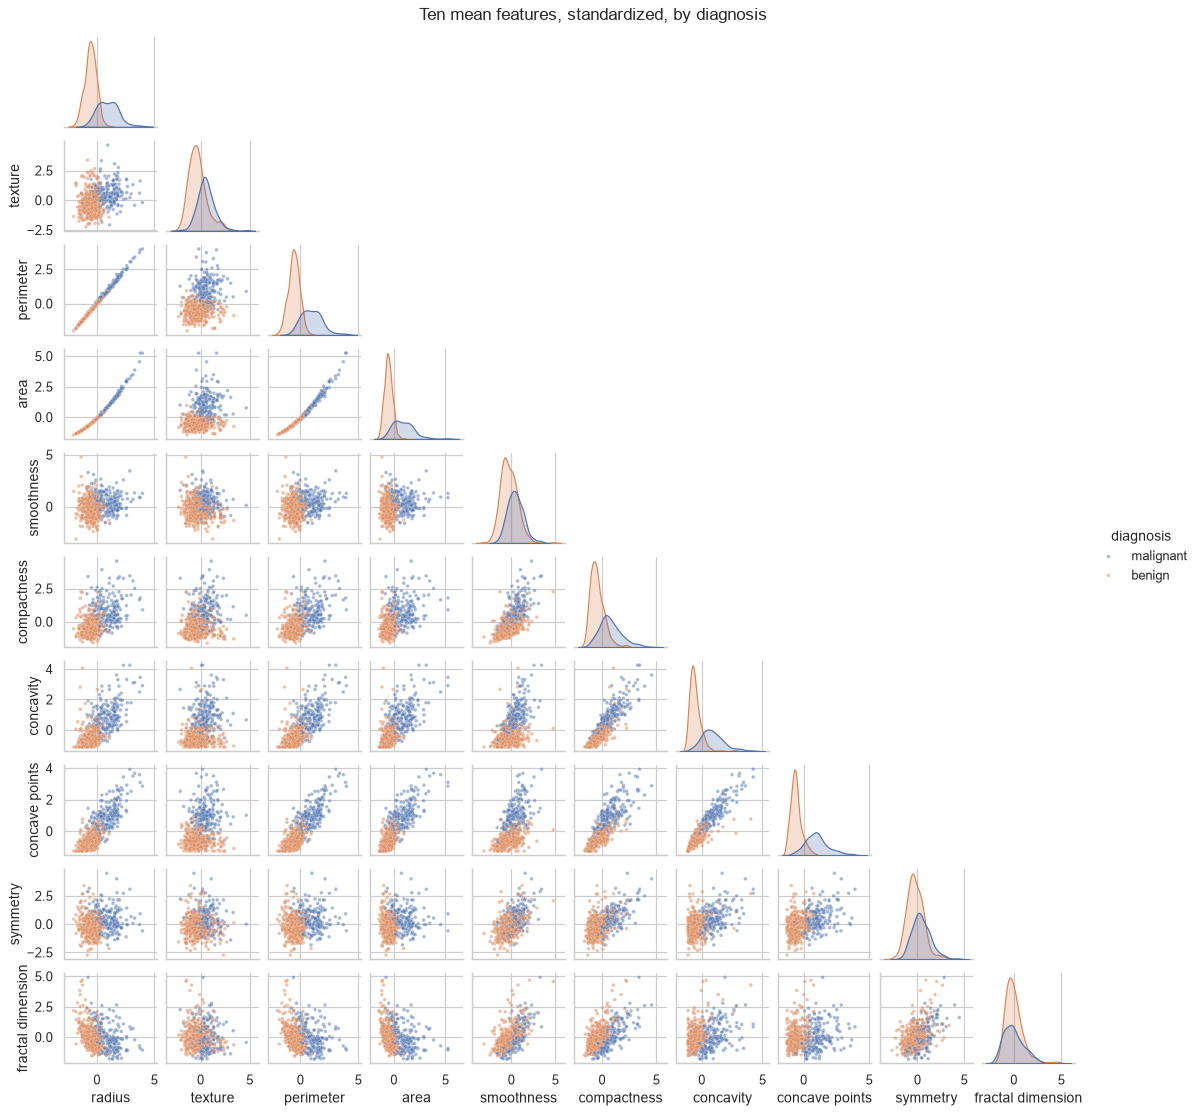

In [7]:
mean_features = [name for name in features if name.startswith("mean")]

pair_data = X_scaled[mean_features].copy()
pair_data.columns = [name.replace("mean ", "") for name in mean_features]
pair_data["diagnosis"] = df["diagnosis"].to_numpy()

sns.pairplot(pair_data, hue="diagnosis", corner=True, height=1.3,
             plot_kws={"s": 9, "alpha": 0.5}, diag_kind="kde")
plt.suptitle("Ten mean features, standardized, by diagnosis", y=1.01)
plt.show()

Two things stand out. The classes overlap but are clearly shifted relative to each other in most panels — malignant samples sit at larger radius, perimeter, area, concavity and concave points — so a distance-based method has a real chance here. And several panels are nearly straight lines: `radius`, `perimeter` and `area` carry almost the same information. That redundancy is quantified next.

## Step 7: Correlation Between Features

Pearson correlation measures the linear relation between features. It is computed on the raw values, since standardization is a linear transformation and does not change the coefficients.

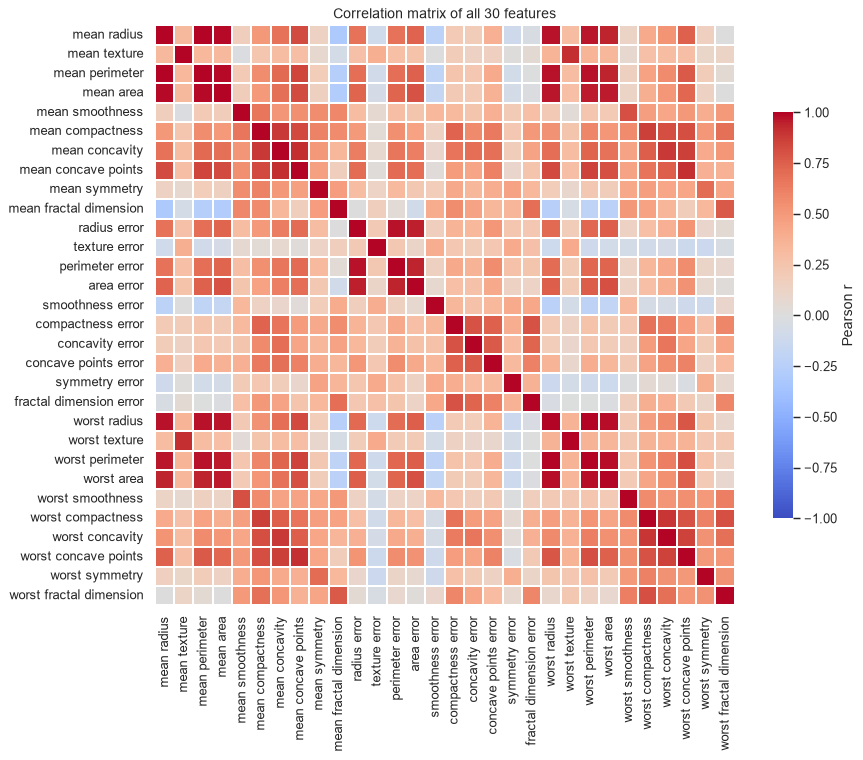

Feature pairs with |r| > 0.9: 21 out of 435

Most correlated pairs:
mean radius      mean perimeter     0.998
worst radius     worst perimeter    0.994
mean radius      mean area          0.987
mean perimeter   mean area          0.987
worst radius     worst area         0.984
worst perimeter  worst area         0.978

Most negatively correlated pairs:
mean perimeter  mean fractal dimension   -0.261
mean area       mean fractal dimension   -0.283
mean radius     mean fractal dimension   -0.312


In [8]:
correlation = X.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(correlation, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.2, cbar_kws={"shrink": 0.7, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation matrix of all 30 features")
plt.tight_layout()
plt.show()

upper = np.triu(np.ones(correlation.shape, dtype=bool), k=1)
pairs = correlation.where(upper).stack().dropna().sort_values(ascending=False)

print(f"Feature pairs with |r| > 0.9: {int((pairs.abs() > 0.9).sum())} out of {len(pairs)}\n")
print("Most correlated pairs:")
print(pairs.head(6).round(3).to_string())
print("\nMost negatively correlated pairs:")
print(pairs.tail(3).round(3).to_string())

In [9]:
target_correlation = X.corrwith(pd.Series(y, index=X.index)).sort_values()

print("Correlation with the target (0 = malignant, 1 = benign):\n")
print(target_correlation.head(6).round(3).to_string())
print("\nWeakest relations:")
print(target_correlation.abs().sort_values().head(4).round(3).to_string())

Correlation with the target (0 = malignant, 1 = benign):

worst concave points   -0.794
worst perimeter        -0.783
mean concave points    -0.777
worst radius           -0.776
mean perimeter         -0.743
worst area             -0.734

Weakest relations:
symmetry error            0.007
texture error             0.008
mean fractal dimension    0.013
smoothness error          0.067


The matrix is dominated by two dense red groups: the size characteristics (radius, perimeter, area) and the shape characteristics (compactness, concavity, concave points), each correlated across its mean and worst variants, while the error block in the middle is visibly weaker. 21 of the 435 feature pairs exceed $|r| = 0.9$, led by `mean radius` / `mean perimeter` at 0.998: for a roughly circular nucleus the perimeter is $2\pi r$ and the area is $\pi r^2$, so these three features are the same measurement expressed three ways.

Against the target the strongest relations are `worst concave points` ($r = -0.794$), `worst perimeter` ($-0.783$) and `mean concave points` ($-0.777$). The sign is negative only because of the encoding: benign is 1, so larger nuclei with more concave contour points mean malignant. `mean fractal dimension` ($r = +0.013$) carries almost no linear information about the diagnosis on its own.

For distance metrics this redundancy matters: 30 features that contain roughly 10 independent measurements means the size-related characteristics are effectively counted three times in every distance sum.

## Step 8: Distance Matrices

Five metrics are requested. For two points $\mathbf{u}, \mathbf{v} \in \mathbb{R}^{30}$:

$$d_{\text{euclidean}} = \sqrt{\sum_i (u_i - v_i)^2}, \qquad
d_{\text{cityblock}} = \sum_i |u_i - v_i|, \qquad
d_{\text{cosine}} = 1 - \frac{\mathbf{u} \cdot \mathbf{v}}{\lVert \mathbf{u} \rVert \lVert \mathbf{v} \rVert}$$

The first two are the $L_2$ and $L_1$ norms of the difference; the third ignores magnitude entirely and compares only direction. Each matrix is $569 \times 569$.

In [10]:
METRICS = ["cityblock", "cosine", "euclidean", "l1", "manhattan"]

distances = {metric: pairwise_distances(X_scaled, metric=metric) for metric in METRICS}

print("Matrix shape:", distances["euclidean"].shape, "\n")
print("Which of the five requested metrics are actually the same?")
for i, first in enumerate(METRICS):
    for second in METRICS[i + 1:]:
        if np.allclose(distances[first], distances[second]):
            print(f"  {first} == {second}")

Matrix shape: (569, 569) 

Which of the five requested metrics are actually the same?
  cityblock == l1
  cityblock == manhattan
  l1 == manhattan


`cityblock`, `l1` and `manhattan` are three names for one metric — the $L_1$ norm — and scikit-learn returns bit-identical matrices for them. Of the five requested metrics only three are distinct, so the comparison below uses `euclidean`, `cityblock` and `cosine`.

A first quantitative comparison: how much larger is the average distance between patients of *different* diagnoses than between patients of the *same* one. The larger this ratio, the better the metric's geometry agrees with the diagnosis.

In [11]:
DISTINCT = ["euclidean", "cityblock", "cosine"]

same_class = y[:, None] == y[None, :]
upper_pairs = np.triu_indices(len(y), k=1)

rows = []
for metric in DISTINCT:
    matrix = distances[metric]
    values = matrix[upper_pairs]
    within = values[same_class[upper_pairs]].mean()
    between = values[~same_class[upper_pairs]].mean()

    rows.append(
        {
            "metric": metric,
            "min": values.min(),
            "max": values.max(),
            "mean_within_class": within,
            "mean_between_class": between,
            "separation_ratio": between / within,
            "silhouette_of_diagnosis": silhouette_score(matrix, y, metric="precomputed"),
        }
    )

pd.DataFrame(rows).round(3)

,metric,min,max,mean_within_class,mean_between_class,separation_ratio,silhouette_of_diagnosis
0,euclidean,1.006,26.882,5.706,8.504,1.490,0.294
1,cityblock,4.273,119.162,24.135,38.959,1.614,0.337
2,cosine,0.023,1.963,0.694,1.306,1.883,0.448


## Step 9: Visualizing the Distance Matrices

Rows and columns are sorted by diagnosis — malignant first, then benign — so that agreement between the metric and the diagnosis appears as a block structure. The dashed lines mark the boundary between the two groups.

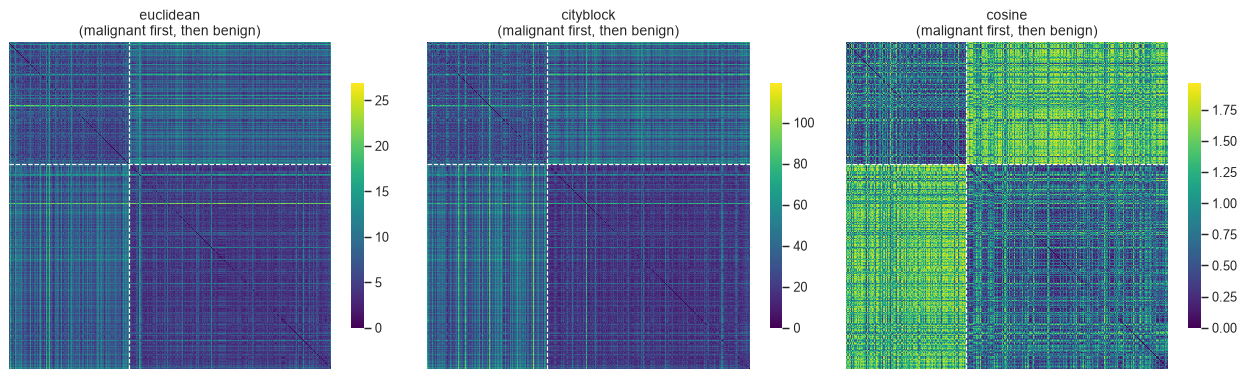

In [12]:
order = np.argsort(y, kind="stable")
boundary = int((y == 0).sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, metric in zip(axes, DISTINCT):
    sorted_matrix = distances[metric][np.ix_(order, order)]
    sns.heatmap(sorted_matrix, cmap="viridis", xticklabels=False, yticklabels=False,
                cbar_kws={"shrink": 0.75}, ax=ax)
    ax.axhline(boundary, color="white", linestyle="--", linewidth=1)
    ax.axvline(boundary, color="white", linestyle="--", linewidth=1)
    ax.set_title(f"{metric}\n(malignant first, then benign)")

plt.tight_layout()
plt.show()

The cosine matrix breaks into an unmistakable 2x2 pattern: both diagonal blocks are dark — malignant patients resemble each other, benign patients resemble each other — while both off-diagonal blocks are bright. The euclidean and cityblock matrices show the same tendency far more weakly, and both are dominated by a few bright rows and columns — individual outlying patients that are far from everyone under an $L_p$ norm, because those norms respond to the magnitude of a deviation while the cosine responds only to its direction.

## Step 10: Clustering on the Distance Matrices

The decisive comparison is whether a clustering algorithm fed with each distance matrix can recover the diagnosis it never saw. Agglomerative clustering accepts a precomputed matrix, which lets the metric be swapped while everything else stays fixed. Results are scored by the Adjusted Rand Index (0 = random, 1 = perfect) and by accuracy after matching each cluster to the class it overlaps most.

In [13]:
LINKAGES = ["average", "complete", "single"]

rows = []
for metric in DISTINCT:
    for linkage in LINKAGES:
        labels = AgglomerativeClustering(
            n_clusters=2, metric="precomputed", linkage=linkage
        ).fit_predict(distances[metric])

        rows.append(
            {
                "metric": metric,
                "linkage": linkage,
                "ARI": adjusted_rand_score(y, labels),
                "accuracy": max(accuracy_score(y, labels), accuracy_score(y, 1 - labels)),
                "cluster_sizes": str(np.bincount(labels).tolist()),
            }
        )

# ward linkage is defined only for euclidean distances and works on the raw coordinates
ward_labels = AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(X_scaled)
rows.append(
    {
        "metric": "euclidean",
        "linkage": "ward",
        "ARI": adjusted_rand_score(y, ward_labels),
        "accuracy": max(accuracy_score(y, ward_labels), accuracy_score(y, 1 - ward_labels)),
        "cluster_sizes": str(np.bincount(ward_labels).tolist()),
    }
)

clustering = pd.DataFrame(rows).sort_values("ARI", ascending=False).reset_index(drop=True)
clustering.round(3)

,metric,linkage,ARI,accuracy,cluster_sizes
0,cosine,average,0.780,0.942,"[378, 191]"
1,cosine,complete,0.693,0.917,"[400, 169]"
2,euclidean,ward,0.575,0.880,"[184, 385]"
3,cityblock,complete,0.546,0.872,"[412, 157]"
4,euclidean,average,0.007,0.633,"[566, 3]"
5,euclidean,complete,0.005,0.631,"[567, 2]"
6,cityblock,single,0.005,0.631,"[2, 567]"
7,cityblock,average,0.005,0.631,"[567, 2]"
8,euclidean,single,0.005,0.631,"[567, 2]"
9,cosine,single,-0.001,0.626,"[568, 1]"


The best combination is **cosine with average linkage: ARI 0.780, accuracy 94.2%** — the diagnosis is recovered almost exactly by a method that only ever saw the distance matrix. Euclidean distance with ward linkage reaches 0.575, cityblock with complete linkage 0.546.

The failures are as informative as the successes. Every combination scoring near zero produced cluster sizes like `[567, 2]`: instead of splitting the data, the algorithm cut off two or three extreme outliers and left everything else in one cluster. This is the chaining effect, and it hits the $L_p$ metrics because they are sensitive to the magnitude of deviations — a patient with extreme values in a few features is far from everyone. Cosine distance is bounded and ignores magnitude, so outliers do not dominate it.

## Step 11: Stability Under Dimensionality Reduction

Since the features are heavily redundant, it is worth checking whether the ranking of the metrics is a property of the metric or an artifact of the 30-dimensional space. The clustering is repeated on PCA projections of increasing size.

In [14]:
rows = []
for n_components in (2, 3, 5, 10, 20, 30):
    model = PCA(n_components=n_components, random_state=RANDOM_STATE)
    reduced = model.fit_transform(X_scaled)

    row = {"components": n_components, "variance_kept": model.explained_variance_ratio_.sum()}
    for metric in DISTINCT:
        labels = AgglomerativeClustering(
            n_clusters=2, metric="precomputed", linkage="average"
        ).fit_predict(pairwise_distances(reduced, metric=metric))
        row[f"ARI_{metric}"] = adjusted_rand_score(y, labels)
    rows.append(row)

compression = pd.DataFrame(rows)
compression.round(3)

,components,variance_kept,ARI_euclidean,ARI_cityblock,ARI_cosine
0,2,0.632,0.058,0.005,0.557
1,3,0.726,0.005,0.011,0.695
2,5,0.847,0.005,0.005,0.666
3,10,0.952,0.007,0.005,0.749
4,20,0.996,0.007,0.007,0.724
5,30,1.000,0.007,0.007,0.780


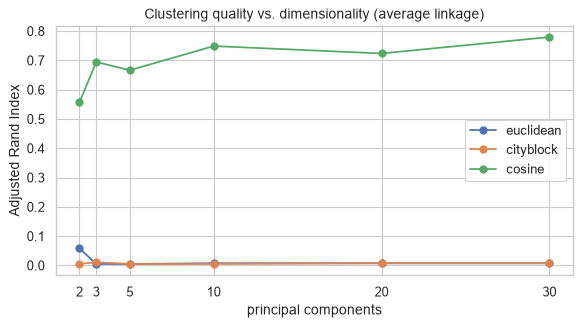

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
for metric in DISTINCT:
    ax.plot(compression["components"], compression[f"ARI_{metric}"], marker="o", label=metric)

ax.set(title="Clustering quality vs. dimensionality (average linkage)",
       xlabel="principal components", ylabel="Adjusted Rand Index")
ax.set_xticks(compression["components"])
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

**The five requested metrics are three.** `cityblock`, `l1` and `manhattan` are different names for the $L_1$ norm and produce bit-identical matrices, verified with `np.allclose`. Only `euclidean`, `cityblock` and `cosine` carry distinct information.

**Standardization is a precondition, not a formality.** The raw features differ in scale by four orders of magnitude — `mean area` spans 143 to 2501 against 0.05 to 0.10 for `mean fractal dimension`. Since every metric here sums contributions across all 30 features, without standardization the distance matrix would be a rescaled copy of the area column.

**The features are strongly redundant.** 21 of 435 pairs exceed $|r| = 0.9$, topped by `mean radius` / `mean perimeter` at 0.998 — geometrically the same quantity, as perimeter and area are functions of radius. The correlation matrix splits into three blocks corresponding to the mean, error and worst versions of the same ten characteristics. Against the diagnosis the strongest predictors are `worst concave points` ($-0.794$) and `worst perimeter` ($-0.783$), while `mean fractal dimension` ($+0.013$) is essentially unrelated. The practical consequence is that the size-related group is effectively triple-counted in every distance.

**Cosine distance is the best metric for this data, by all three measures.** They agree on the same ranking:

| metric | separation ratio | silhouette of the diagnosis | best clustering (ARI) |
| --- | --- | --- | --- |
| cosine | 1.883 | 0.448 | **0.780** (average linkage, 94.2% accuracy) |
| cityblock | 1.614 | 0.337 | 0.546 (complete linkage) |
| euclidean | 1.490 | 0.294 | 0.575 (ward linkage) |

The reason is the structure of the data. A malignant sample is characterized by a *profile* — simultaneously elevated radius, perimeter, area, concavity and concave points — rather than by the magnitude of the deviation. Cosine distance compares exactly that profile, being invariant to the length of the vector, while $L_1$ and $L_2$ grow with the size of the deviation and therefore let a handful of extreme patients dominate the geometry. This shows up directly in the heatmaps as bright rows and columns, and in clustering as the degenerate `[567, 2]` splits that average and single linkage produce for the $L_p$ metrics.

**The metric matters more than the number of dimensions, but linkage matters as much as the metric.** Across PCA projections from 2 to 30 components cosine stays in the 0.56–0.78 band while both $L_p$ metrics stay near zero, so the ranking is a property of the metric rather than of the dimensionality. Yet on the same euclidean distances the choice of linkage moves the result from 0.007 (average) to 0.575 (ward) — a reminder that a distance metric alone does not define a clustering, and that a poor result is not always the metric's fault.